# BDF Quickstart

This notebook shows a minimal workflow using the **bdf** package:

1. **Detect** which cycler produced a raw file (e.g., Bio-Logic `.mpt`)
2. **Normalize** the raw file into **BDF** canonical columns
3. **Visualize** with line plots (e.g., `Voltage / V` vs `Test Time / s`)

**Prerequisite:** from the repository root, run `pip install -e .` once in your environment so the `bdf` package is importable.


In [17]:
from pathlib import Path
import pandas as pd

# Core BDF API
from bdf import detect_cycler, read_raw_to_bdf
from bdf.io import load as load_bdf, save_csv
from bdf.visualize import line_plot
from bdf import read_raw_to_bdf, validate_bdf

# (Optional) nicer display
pd.set_option("display.max_columns", 50)


## Configure paths

Update `RAW_FILE` if your file lives elsewhere.  
The normalized BDF output will be written to `out/demo.bdf.csv`.


In [18]:
from bdf import load_registry, get_entry, load_bdf_from_entry
from bdf.visualize import line_plot
from bdf import validate_bdf

# loads ../data/datasets.json automatically (from repo root); or load_registry("../data/datasets.json")
REG = load_registry()
BDF_OUT  = Path("./out/demo.bdf.csv")
BDF_OUT.parent.mkdir(parents=True, exist_ok=True)

# pick an item (case-insensitive keys)
entry = get_entry(REG, "neware", "li-ion", "rate", "non-monotonic-time")

local_path, df_bdf = load_bdf_from_entry(entry)
print("Fetched to:", local_path)


Fetched to: C:\Users\simonc\AppData\Local\bdf\bdf\Cache\SINTEF__SLPBA842124HV__2024-10-23__Rate_25degC__Neware__Time_Bug.csv


In [19]:
# ---- Validate in-memory and print full report (warnings included) ----
report = validate_bdf(df_bdf)   # use strict=True to raise on errors
print(report)                   # nicely formatted: errors + warnings

# (Optional) fail the notebook if invalid
if not report.ok:
    raise RuntimeError("BDF validation failed. See errors above.")

Warnings:
  - Minor non-monotonic time detected (19 drops).
  - Potential outliers in Current / A: 195 points (1.49%) flagged by robust MAD z>8.0. Examples: -32.7475, -32.7475, -32.7492


## Visualize

Plot simple **Voltage vs Time** and **Current vs Time** line plots.  
You can change `xdata` / `ydata` to any BDF column names (e.g., `"Current / A"`, `"Ambient Temperature / degC"`).


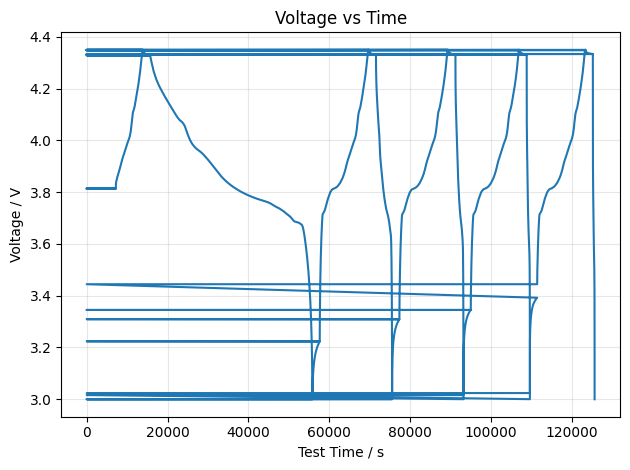

In [20]:
# Voltage vs Time
_ = line_plot(
    df_bdf,
    xdata="Test Time / s",
    ydata="Voltage / V",
    title="Voltage vs Time",
    save="out/voltage_vs_time.png",
)

## Clean Bugs

Rows: 13086 → 13086
Time fix: segment (resets=431)
Outliers: none (z>8)


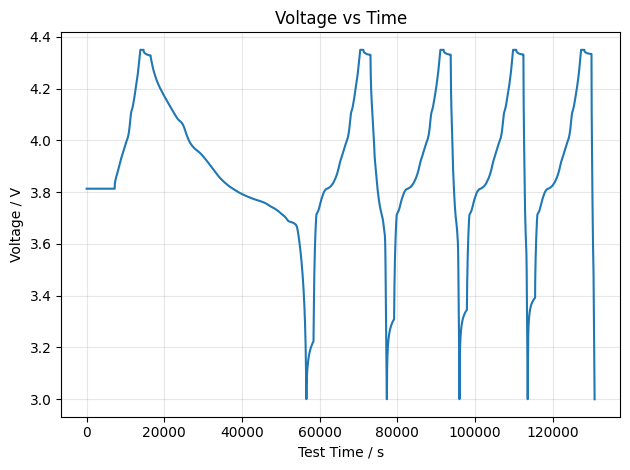

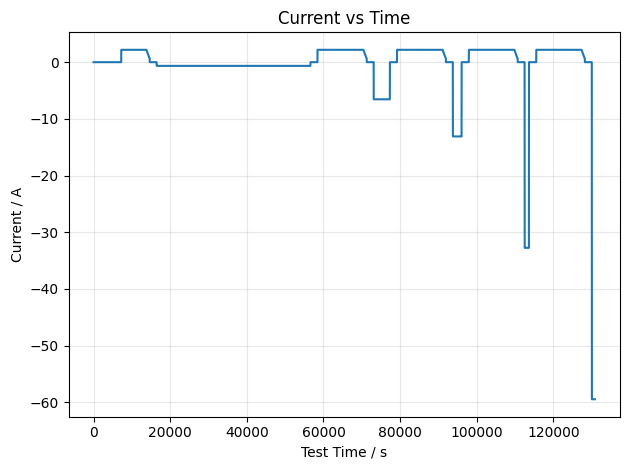

In [21]:
from bdf import load_registry, get_entry, load_bdf_from_entry, validate_bdf, clean_bdf
from bdf.io import save_csv
from bdf.visualize import line_plot
from pathlib import Path

df_clean, rep = clean_bdf(
    df_bdf,
    time_fix="segment"
)
print(rep)

# Plot after cleaning
# Voltage vs Time
fig1 = line_plot(
    df_clean,
    xdata="Test Time / s",
    ydata="Voltage / V",
    title="Voltage vs Time",
    save="out/voltage_vs_time.png",
)

# Current vs Time
fig2 = line_plot(
    df_clean,
    xdata="Test Time / s",
    ydata="Current / A",
    title="Current vs Time",
    save="out/current_vs_time.png",
)


## Metadata

In [22]:
from bdf import BDFMetadata, Creator, RelatedIdentifier, save_jsonld
import json

# Suppose you just produced a BDF CSV:
data_path = Path("./out/demo.bdf.csv")

meta = BDFMetadata(
    title="Neware Rate Test of Li-ion Cell with Non-monotonic Time Bug (cleaned)",
    creators=[
        Creator(name="Simon C...", orcid="0000-0002-1825-0097", affiliation="Battery Data Alliance"),
        Creator(name="Jane Doe", affiliation="SINTEF"),
    ],
    description=(
        "Example dataset used to demonstrate the BDF detect→normalize→validate→clean→visualize pipeline. "
        "Includes intentional time and signal outliers for validator demos."
    ),
    keywords=["battery", "cycling", "BDF", "Li-ion", "NEWARE"],
    license="CC-BY-4.0",
    access_right="open",
    version="0.1.0",
    publication_date="2025-08-25",
    related_identifiers=[
        RelatedIdentifier(relation="isSupplementTo", scheme="url", identifier="https://github.com/.../battery-data-format"),
    ],
    communities=["battery-data"],  # Zenodo community slugs if applicable
)

# If you have the DataFrame in memory (to include per-column metadata), pass df=
# df = load_bdf(data_path)  # or the df you just created
jsonld_path = save_jsonld(meta, data_path, df=None)  # or df=df
jsonld_path

jsonld_doc = meta.to_jsonld(data_path, df=None)
# and plain text if you also want it:
print(json.dumps(jsonld_doc, indent=2, ensure_ascii=False))


{
  "@context": {
    "schema": "https://schema.org/",
    "dcat": "http://www.w3.org/ns/dcat#",
    "dct": "http://purl.org/dc/terms/",
    "csvw": "http://www.w3.org/ns/csvw#",
    "url": "csvw:url",
    "tableSchema": {
      "@id": "csvw:tableSchema",
      "@type": "@id"
    },
    "sameAs": {
      "@id": "schema:sameAs",
      "@type": "@id"
    }
  },
  "@graph": [
    {
      "@id": "https://w3id.org/battery-data-alliance/datasets/ab0b4a22-0b21-556c-bfdd-d19bc72fe4df",
      "@type": [
        "schema:Dataset",
        "dcat:Dataset"
      ],
      "schema:name": "Neware Rate Test of Li-ion Cell with Non-monotonic Time Bug (cleaned)",
      "schema:description": "Example dataset used to demonstrate the BDF detect→normalize→validate→clean→visualize pipeline. Includes intentional time and signal outliers for validator demos.",
      "schema:creator": [
        {
          "@type": "schema:Person",
          "schema:name": "Simon C...",
          "schema:affiliation": {
         

### (Optional) Save normalized BDF to disk


In [23]:
print(validate_bdf(df_clean))
save_csv(df_clean, BDF_OUT)
print(f"Wrote: {BDF_OUT.resolve()}")

Warnings:
  - Potential outliers in Current / A: 195 points (1.49%) flagged by robust MAD z>8.0. Examples: -32.7475, -32.7475, -32.7492
Wrote: C:\Users\simonc\Documents\Github-local\battery_data_alliance\battery-data-format\examples\out\demo.bdf.csv


## Load a BDF file directly and plot

If you already have a BDF CSV/Parquet, load with `bdf.io.load` and plot immediately.


True [] ['Potential outliers in Current / A: 195 points (1.49%) flagged by robust MAD z>8.0. Examples: -32.7475, -32.7475, -32.7492']
Saved plot → out/vi_vs_time.png


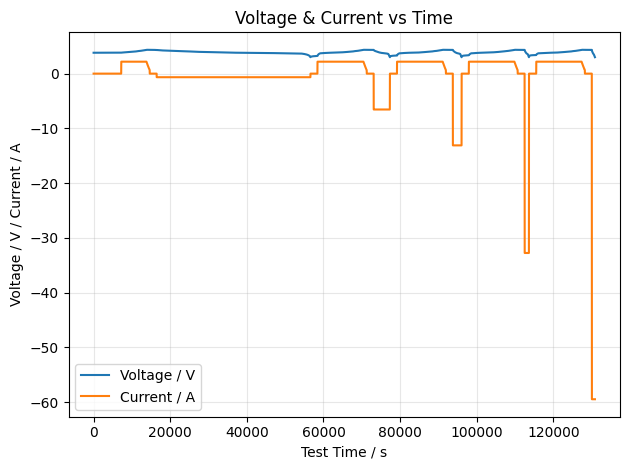

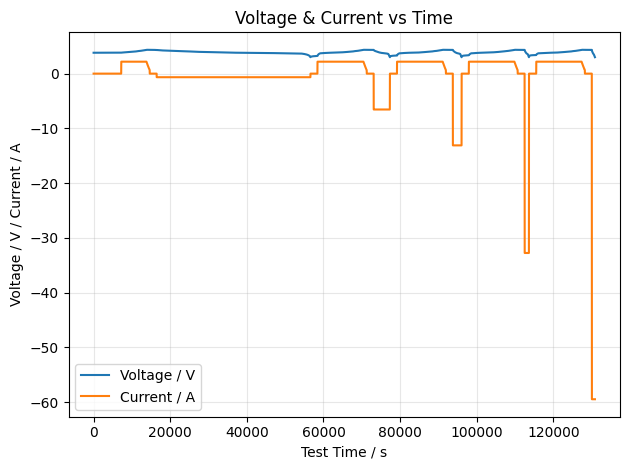

In [24]:
# validate an external file that claims to be BDF:
report = validate_bdf(BDF_OUT)
print(report.ok, report.errors, report.warnings)

df2 = load_bdf(BDF_OUT)

fig3 = line_plot(
    df2,
    xdata="Test Time / s",
    ydata=["Voltage / V", "Current / A"],
    title="Voltage & Current vs Time",
    save="out/vi_vs_time.png",
)
print("Saved plot → out/vi_vs_time.png")
fig3
